In [48]:
# import python library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Upload Dataset form Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/iris.csv')

In [51]:
df

,Unnamed: 0,sepal_length,sepal_width,petal_length,petal_width,species
0,0,5.1,3.5,1.4,0.2,setosa
1,1,4.9,3.0,1.4,0.2,setosa
2,2,4.7,3.2,1.3,0.2,setosa
3,3,4.6,3.1,1.5,0.2,setosa
4,4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...,...
145,145,6.7,3.0,5.2,2.3,versicolor
146,146,6.3,2.5,5.0,1.9,versicolor
147,147,6.5,3.0,5.2,2.0,versicolor
148,148,6.2,3.4,5.4,2.3,versicolor


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    150 non-null    int64  
 1   sepal_length  150 non-null    float64
 2   sepal_width   150 non-null    float64
 3   petal_length  150 non-null    float64
 4   petal_width   150 non-null    float64
 5   species       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [91]:
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [53]:
# Drop unnecessary features
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,versicolor
146,6.3,2.5,5.0,1.9,versicolor
147,6.5,3.0,5.2,2.0,versicolor
148,6.2,3.4,5.4,2.3,versicolor


In [54]:
# Apply Label Encoder for species feature
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [55]:
# Fit and Transform on Species
dataset = le.fit_transform(df['species'])

In [56]:
# Convert array to Data Frame
species_le = pd.DataFrame(dataset, columns=['species'])

In [57]:
# Drop None Encoded target Feature
df.drop(['species'], axis=1, inplace=True)

In [58]:
# Concate Encoded Feature with Original Data Frame
dset = pd.concat([df, species_le], axis=1)

In [59]:
dset

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [60]:
# Rename dset to df
df = dset

In [61]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [62]:
# Define input and output/target features
X = df.drop(['species'], axis=1)
y = df['species']

In [72]:
# Apply Scaler for input/independent features
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [73]:
# Scale input/independent features
X_scale = scale.fit_transform(X)
X_scale

array([[-0.650949  ,  0.89047961, -1.06601023, -1.07455577],
       [-0.92741382, -0.18121357, -1.06601023, -1.07455577],
       [-1.20387864,  0.2474637 , -1.12779164, -1.07455577],
       [-1.34211106,  0.03312506, -1.00422881, -1.07455577],
       [-0.78918141,  1.10481825, -1.06601023, -1.07455577],
       [-0.23625176,  1.74783416, -0.88066598, -0.76753983],
       [-1.34211106,  0.67614097, -1.06601023, -0.9210478 ],
       [-0.78918141,  0.67614097, -1.00422881, -1.07455577],
       [-1.61857588, -0.39555221, -1.06601023, -1.07455577],
       [-0.92741382,  0.03312506, -1.00422881, -1.22806373],
       [-0.23625176,  1.31915688, -1.00422881, -1.07455577],
       [-1.06564623,  0.67614097, -0.9424474 , -1.07455577],
       [-1.06564623, -0.18121357, -1.06601023, -1.22806373],
       [-1.75680829, -0.18121357, -1.25135447, -1.22806373],
       [ 0.31667789,  1.96217279, -1.18957306, -1.07455577],
       [ 0.17844548,  2.81952734, -1.00422881, -0.76753983],
       [-0.23625176,  1.

In [74]:
# Imbalance Target Feature
X = X_scale[:110]
y = y[:110]

In [75]:
# Apply SMOTE on X and y
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

In [76]:
# Apply PCA for column reduction
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_resampled_pca = pca.transform(X_resampled)

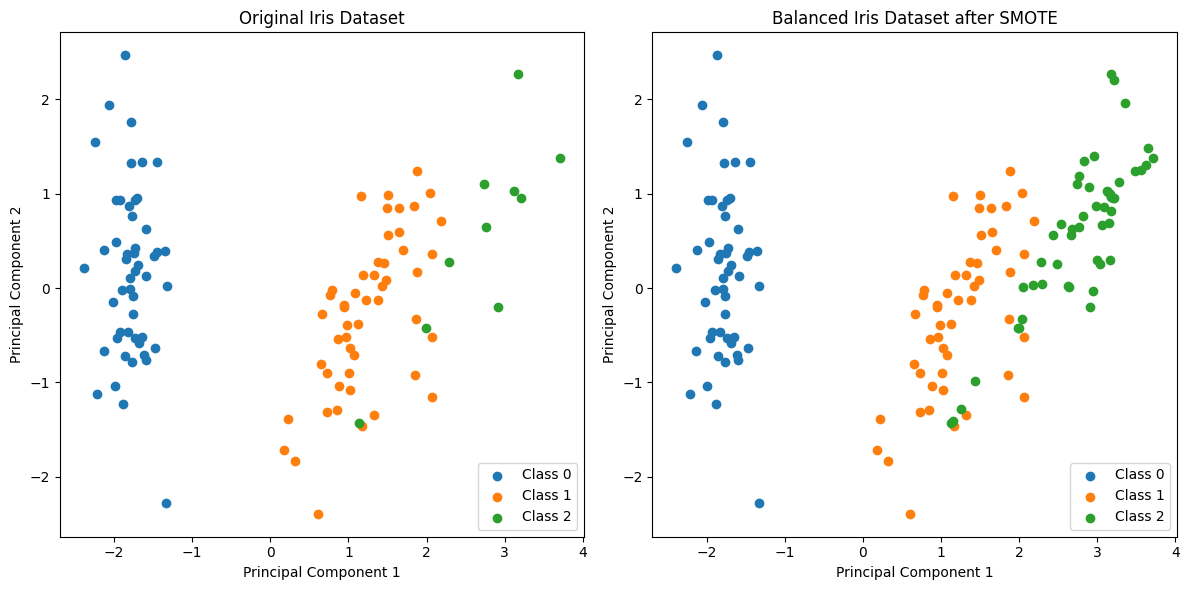

In [77]:
# Apply Scatter plot for visualize data
plt.figure(figsize=(12, 6))

# Plot original dataset
plt.subplot(1, 2, 1)
for i in range(3):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=f'Class {i}')
plt.title('Original Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

# Plot balanced dataset after SMOTE
plt.subplot(1, 2, 2)
for i in range(3):
    plt.scatter(X_resampled_pca[y_resampled == i, 0], X_resampled_pca[y_resampled == i, 1], label=f'Class {i}')
plt.title('Balanced Iris Dataset after SMOTE')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.tight_layout()
plt.show()

In [81]:
list(y).count(1), list(y_resampled).count(1)

(50, 40)

In [78]:
# Split train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size=0.2, random_state=42)

In [79]:
# Apply SMOTE on Train and Test Data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [80]:
list(y_train).count(1), list(y_resampled).count(1)

(39, 40)

In [82]:
# Apply KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

In [87]:
# Observe KNN performance and pick the best performed K value
accuracy_train_list = []
accuracy_test_list  = []
f1_train_list       = []
f1_test_list        = []
k_values = []

for i in range(3, 13):
    print('k:', i)
    k_values.append(i)

    KNN = KNeighborsClassifier(n_neighbors=i)
    KNN.fit(X_resampled, y_resampled)

    y_pred_train = KNN.predict(X_train)

    accuracy_train = accuracy_score(y_pred_train, y_train)
    accuracy_train_list.append(accuracy_train)

    f1_train = f1_score(y_pred_train, y_train, average=None)
    f1_train_list.append(f1_train)

    y_pred_test = KNN.predict(X_test)

    accuracy_test = accuracy_score(y_pred_test, y_test)
    accuracy_test_list.append(accuracy_test)

    f1_test = f1_score(y_pred_test, y_test, average=None)
    f1_test_list.append(f1_test)

    print(accuracy_train, accuracy_test)
    print(f1_train, f1_test, '\n')

k: 3
0.9886363636363636 1.0
[1.         0.98701299 0.94736842] [1. 1. 1.] 

k: 4
0.9886363636363636 1.0
[1.         0.98734177 0.94117647] [1. 1. 1.] 

k: 5
0.9886363636363636 1.0
[1.         0.98734177 0.94117647] [1. 1. 1.] 

k: 6
0.9886363636363636 1.0
[1.         0.98734177 0.94117647] [1. 1. 1.] 

k: 7
0.9886363636363636 1.0
[1.         0.98734177 0.94117647] [1. 1. 1.] 

k: 8
0.9886363636363636 1.0
[1.         0.98734177 0.94117647] [1. 1. 1.] 

k: 9
0.9886363636363636 1.0
[1.         0.98734177 0.94117647] [1. 1. 1.] 

k: 10
0.9772727272727273 1.0
[1.    0.975 0.875] [1. 1. 1.] 

k: 11
0.9772727272727273 1.0
[1.    0.975 0.875] [1. 1. 1.] 

k: 12
0.9772727272727273 1.0
[1.    0.975 0.875] [1. 1. 1.] 



<ipython-input-88-4eca0d1b8dee>:4: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend('Train', 'Test')


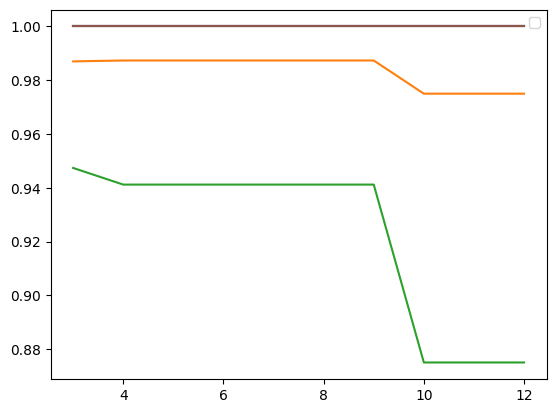

In [88]:
# Plot on KNN result
plt.plot(list(range(3, 13)),f1_train_list)
plt.plot(list(range(3, 13)),f1_test_list)
plt.legend('Train', 'Test')
plt.show()

In [90]:
# Apply KNN on best performed K value
KNN = KNeighborsClassifier(n_neighbors=9)
KNN.fit(X_train, y_train)

y_pred_train = KNN.predict(X_train)
accuracy_train = accuracy_score(y_pred_train, y_train)
f1_train = f1_score(y_pred_train, y_train, average=None)

y_pred_test = KNN.predict(X_test)
accuracy_test = accuracy_score(y_pred_test, y_test)
f1_test = f1_score(y_pred_test, y_test, average=None)

In [92]:
# Apply Classification Report
from sklearn.metrics import classification_report
target_names = ['setosa', 'verginica', 'versicolor']

In [93]:
# Show the over all performance on train data
print('Train Data of KNN: ','\n')
print('Accuracy on Train Data: ', accuracy_train, '\n')
print('F1_Score on Train Data: ', f1_train, '\n')
print('Classification Report on Train Data: ', '\n', '\n', classification_report(y_pred_train, y_train, target_names=target_names))

Train Data of KNN:  

Accuracy on Train Data:  0.9545454545454546 

F1_Score on Train Data:  [1.         0.95121951 0.71428571] 

Classification Report on Train Data:  
 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        40
   verginica       1.00      0.91      0.95        43
  versicolor       0.56      1.00      0.71         5

    accuracy                           0.95        88
   macro avg       0.85      0.97      0.89        88
weighted avg       0.97      0.95      0.96        88



In [94]:
# Show the over all performance on test data
print('Test Data of KNN: ','\n')
print('Accuracy on Test Data: ', accuracy_test, '\n' )
print('F1 Score on Test Data: ', f1_test, '\n')
print('Classification Report on Test Data: ', '\n','\n', classification_report(y_pred_test, y_test))

Test Data of KNN:  

Accuracy on Test Data:  0.9545454545454546 

F1 Score on Test Data:  [1.         0.95652174 0.        ] 

Classification Report on Test Data:  
 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        12
           2       0.00      0.00      0.00         0

    accuracy                           0.95        22
   macro avg       0.67      0.64      0.65        22
weighted avg       1.00      0.95      0.98        22



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [95]:
# Apply Confusion Matrix
from sklearn.metrics import confusion_matrix
c_train = confusion_matrix(y_pred_train, y_train)
c_test  = confusion_matrix(y_pred_test, y_test)

In [96]:
# Results of Confusion Matrix on train and test data
print('Confusion Matrix on Train Data: ','\n', c_train, '\n')
print('Confusion Matrix on Test  Data: ', '\n', c_test)

Confusion Matrix on Train Data:  
 [[40  0  0]
 [ 0 39  4]
 [ 0  0  5]] 

Confusion Matrix on Test  Data:  
 [[10  0  0]
 [ 0 11  1]
 [ 0  0  0]]


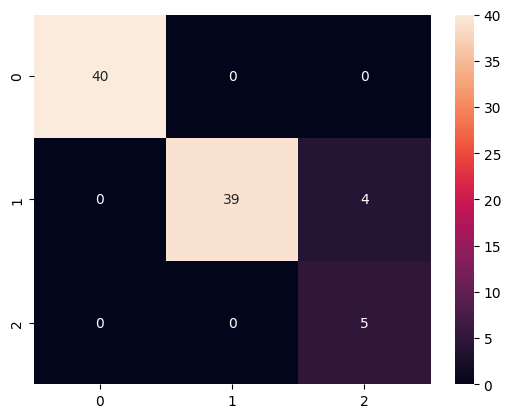

In [97]:
# Apply heatmap on train Data
sns.heatmap(c_train, annot=True)
plt.show()

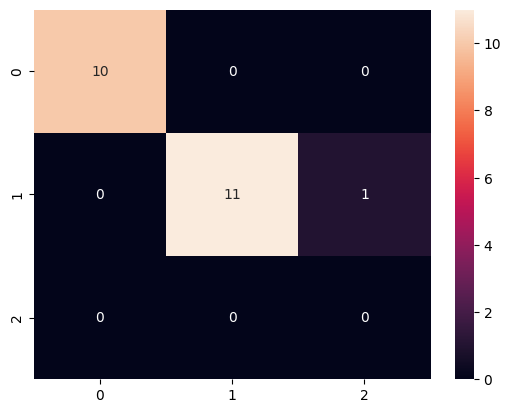

In [98]:
# Apply heatmap on test Data
sns.heatmap(c_test, annot=True)
plt.show()